In [7]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb
from scipy.signal import butter, filtfilt, iirnotch, welch


In [8]:
PROJECT_DIR = Path.cwd()

DATASET_DIR = PROJECT_DIR / "ptb-diagnostic-ecg-database-1.0.0"

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

detection_path = PROCESSED_DIR / "ptb_detection_records.csv"

print("Project directory:", PROJECT_DIR)
print("Dataset exists:", DATASET_DIR.exists())
print("Detection file exists:", detection_path.exists())

if not detection_path.exists():
    raise FileNotFoundError(
        "ptb_detection_records.csv not found. Please run Notebook 1 first."
    )

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Dataset exists: True
Detection file exists: True


In [9]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_MID = "#B77FA0"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_VERY_LIGHT = "#F5EAF1"
GRAY = "#6B6B6B"

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [10]:
detection_df = pd.read_csv(detection_path)

print("Detection dataset shape:", detection_df.shape)

print("\nRecord-level class distribution:")
display(detection_df["mi_detected"].value_counts())

print("\nPatient-level class distribution:")
display(
    detection_df
    .groupby("patient_id")["mi_detected"]
    .agg(lambda x: x.mode().iloc[0])
    .value_counts()
)

display(detection_df.head())

Detection dataset shape: (448, 15)

Record-level class distribution:


mi_detected
1    368
0     80
Name: count, dtype: int64


Patient-level class distribution:


mi_detected
1    148
0     52
Name: count, dtype: int64

,patient_id,record_id,record_path,age,sex,reason_for_admission,raw_localization,fs,n_sig,sig_len,duration_sec,comments_text,mi_detected,healthy_control,broad_group
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,38400,38.4,age: 81 | sex: female | ECG date: 01/10/1990 |...,1,0,Myocardial Infarction
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 17/10/1990 |...,1,0,Myocardial Infarction
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 18/10/1990 |...,1,0,Myocardial Infarction
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,58.0,female,Myocardial infarction,anterior,1000,15,115200,115.2,age: 58 | sex: female | ECG date: 17/10/1990 |...,1,0,Myocardial Infarction
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,63.0,male,Myocardial infarction,infero-lateral+infero-postero-lateral+posterio...,1000,15,115200,115.2,age: 63 | sex: male | ECG date: 18/10/1990 | D...,1,0,Myocardial Infarction


In [11]:
STANDARD_12_LEADS = [
    "i", "ii", "iii",
    "avr", "avl", "avf",
    "v1", "v2", "v3", "v4", "v5", "v6"
]

LEAD_DISPLAY_NAMES = {
    "i": "I",
    "ii": "II",
    "iii": "III",
    "avr": "aVR",
    "avl": "aVL",
    "avf": "aVF",
    "v1": "V1",
    "v2": "V2",
    "v3": "V3",
    "v4": "V4",
    "v5": "V5",
    "v6": "V6"
}

print(STANDARD_12_LEADS)

['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']


# Load and inspect ECG records

In [12]:
def load_ecg_record(record_path_relative):
    """
    Load one ECG record using WFDB.

    Parameters
    ----------
    record_path_relative : str
        Path without file extension, relative to PROJECT_DIR.

    Returns
    -------
    signal : np.ndarray
        ECG signal, shape = (n_samples, n_channels)
    fs : int or float
        Sampling frequency
    lead_names : list
        Channel names in lowercase
    record_info : dict
        Additional metadata
    """
    record_path = PROJECT_DIR / record_path_relative

    signal, fields = wfdb.rdsamp(str(record_path))

    lead_names = [str(ch).lower() for ch in fields["sig_name"]]
    fs = fields["fs"]

    record_info = {
        "fs": fs,
        "lead_names": lead_names,
        "units": fields.get("units", None),
        "n_samples": signal.shape[0],
        "n_channels": signal.shape[1],
        "duration_sec": signal.shape[0] / fs
    }

    return signal, fs, lead_names, record_info

In [13]:
def select_standard_12_leads(signal, lead_names):
    """
    Select and reorder ECG signal to standard 12-lead order.

    Output lead order:
    I, II, III, aVR, aVL, aVF, V1-V6
    """
    lead_to_idx = {lead.lower(): idx for idx, lead in enumerate(lead_names)}

    missing_leads = [
        lead for lead in STANDARD_12_LEADS
        if lead not in lead_to_idx
    ]

    if len(missing_leads) > 0:
        raise ValueError(f"Missing leads: {missing_leads}")

    selected_indices = [lead_to_idx[lead] for lead in STANDARD_12_LEADS]
    selected_signal = signal[:, selected_indices]

    return selected_signal, STANDARD_12_LEADS

In [14]:
mi_example_row = detection_df[detection_df["mi_detected"] == 1].iloc[0]
healthy_example_row = detection_df[detection_df["mi_detected"] == 0].iloc[0]

print("MI example:")
display(mi_example_row[["patient_id", "record_id", "record_path", "reason_for_admission"]])

print("\nHealthy example:")
display(healthy_example_row[["patient_id", "record_id", "record_path", "reason_for_admission"]])

MI example:


patient_id                                                     patient001
record_id                                                        s0010_re
record_path             ptb-diagnostic-ecg-database-1.0.0\patient001\s...
reason_for_admission                                Myocardial infarction
Name: 0, dtype: object


Healthy example:


patient_id                                                     patient104
record_id                                                        s0306lre
record_path             ptb-diagnostic-ecg-database-1.0.0\patient104\s...
reason_for_admission                                      Healthy control
Name: 316, dtype: object

In [16]:
raw_signal, fs, lead_names, record_info = load_ecg_record(mi_example_row["record_path"])
raw_12lead, selected_leads = select_standard_12_leads(raw_signal, lead_names)

print("Original signal shape:", raw_signal.shape)
print("Selected 12-lead signal shape:", raw_12lead.shape)
print("Sampling frequency:", fs)
print("Duration (s):", record_info["duration_sec"])
print("Original lead names:", lead_names)
print("Selected lead names:", selected_leads)

print("\nSignal units:", record_info["units"])

Original signal shape: (38400, 15)
Selected 12-lead signal shape: (38400, 12)
Sampling frequency: 1000
Duration (s): 38.4
Original lead names: ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'vx', 'vy', 'vz']
Selected lead names: ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']

Signal units: ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


In [17]:
def plot_multilead_ecg(
    signal,
    fs,
    lead_names,
    title,
    output_path=None,
    start_sec=0,
    duration_sec=5,
    vertical_spacing=None
):
    """
    Plot multi-lead ECG signals with vertical offset.
    """
    start_sample = int(start_sec * fs)
    end_sample = int((start_sec + duration_sec) * fs)

    segment = signal[start_sample:end_sample, :]
    t = np.arange(segment.shape[0]) / fs + start_sec

    if vertical_spacing is None:
        # robust spacing based on signal variability
        vertical_spacing = 3 * np.nanmedian(np.std(segment, axis=0))
        if vertical_spacing == 0 or np.isnan(vertical_spacing):
            vertical_spacing = 1.0

    plt.figure(figsize=(14, 8))

    n_leads = segment.shape[1]

    for i in range(n_leads):
        offset = (n_leads - 1 - i) * vertical_spacing
        lead_label = LEAD_DISPLAY_NAMES.get(lead_names[i], lead_names[i])

        plt.plot(
            t,
            segment[:, i] + offset,
            linewidth=1.0,
            color=PURPLE_DARK
        )

        plt.text(
            t[0],
            offset,
            lead_label,
            va="center",
            ha="right",
            fontsize=10,
            color="black"
        )

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude with vertical offset")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

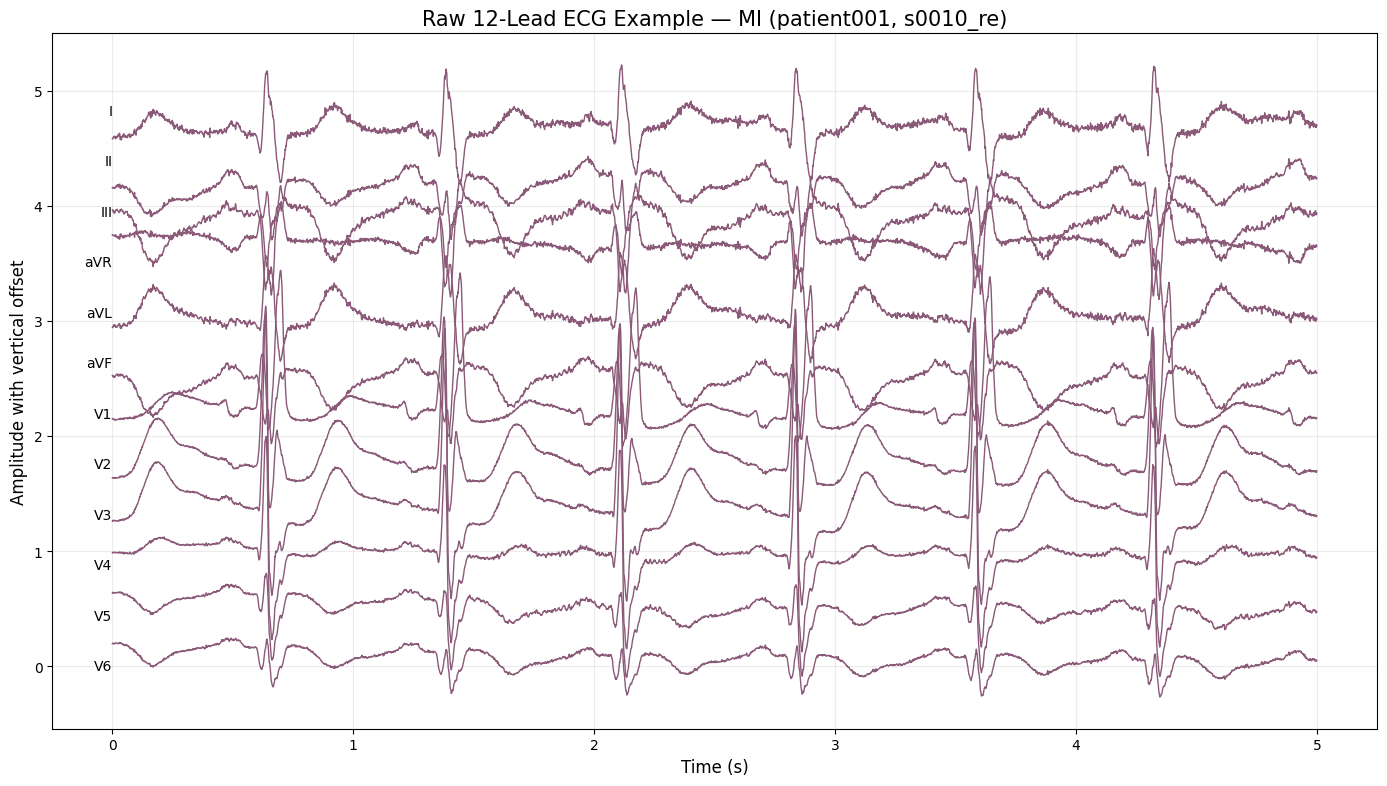

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook2_raw_12lead_mi_example.png


In [18]:
fig_path = FIGURE_DIR / "notebook2_raw_12lead_mi_example.png"

plot_multilead_ecg(
    raw_12lead,
    fs,
    selected_leads,
    title=f"Raw 12-Lead ECG Example — MI ({mi_example_row['patient_id']}, {mi_example_row['record_id']})",
    output_path=fig_path,
    start_sec=0,
    duration_sec=5
)

print("Saved figure to:", fig_path)

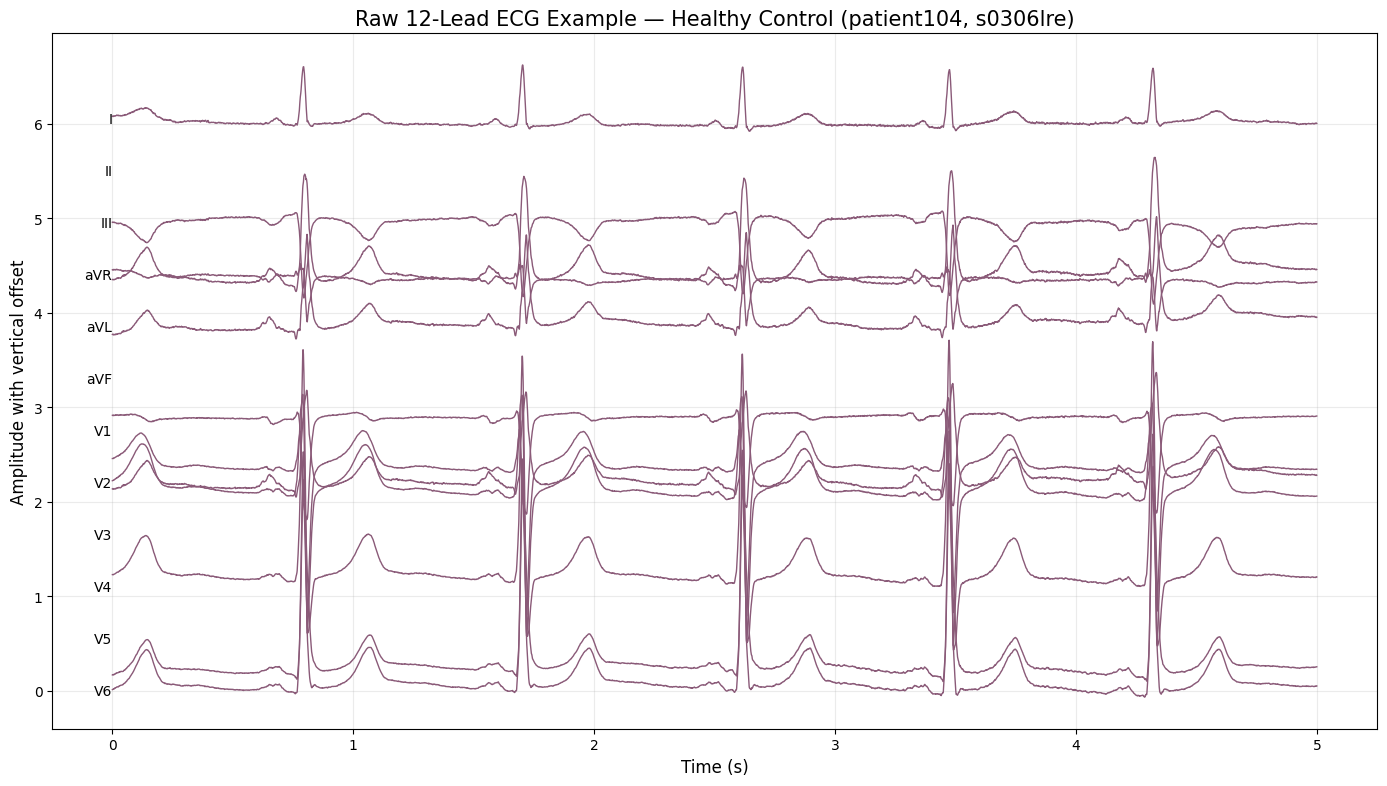

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook2_raw_12lead_healthy_example.png


In [19]:
healthy_raw_signal, healthy_fs, healthy_lead_names, healthy_info = load_ecg_record(
    healthy_example_row["record_path"]
)

healthy_raw_12lead, healthy_selected_leads = select_standard_12_leads(
    healthy_raw_signal,
    healthy_lead_names
)

fig_path = FIGURE_DIR / "notebook2_raw_12lead_healthy_example.png"

plot_multilead_ecg(
    healthy_raw_12lead,
    healthy_fs,
    healthy_selected_leads,
    title=f"Raw 12-Lead ECG Example — Healthy Control ({healthy_example_row['patient_id']}, {healthy_example_row['record_id']})",
    output_path=fig_path,
    start_sec=0,
    duration_sec=5
)

print("Saved figure to:", fig_path)

In [20]:
PREPROCESSING_CONFIG = {
    "bandpass_low_hz": 0.5,
    "bandpass_high_hz": 40.0,
    "notch_hz": 50.0,
    "notch_quality_factor": 30.0,
    "apply_notch": True,
    "normalization": "per_lead_z_score"
}

print(json.dumps(PREPROCESSING_CONFIG, indent=4))

{
    "bandpass_low_hz": 0.5,
    "bandpass_high_hz": 40.0,
    "notch_hz": 50.0,
    "notch_quality_factor": 30.0,
    "apply_notch": true,
    "normalization": "per_lead_z_score"
}


In [27]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    Zero-phase Butterworth bandpass filter.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="bandpass")
    filtered = filtfilt(b, a, signal, axis=0)

    return filtered


def notch_filter(signal, fs, notch_freq=50.0, quality_factor=30.0):
    """
    Zero-phase notch filter for powerline interference.
    """
    b, a = iirnotch(
        w0=notch_freq,
        Q=quality_factor,
        fs=fs
    )

    filtered = filtfilt(b, a, signal, axis=0)

    return filtered


def zscore_normalize_per_lead(signal, eps=1e-8):
    """
    Per-lead z-score normalization.
    """
    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)

    normalized = (signal - mean) / (std + eps)

    return normalized, mean, std

In [28]:
def preprocess_ecg_signal(signal, fs, config=PREPROCESSING_CONFIG):
    """
    Apply ECG preprocessing:
    1. Bandpass filtering
    2. Optional notch filtering
    3. Per-lead z-score normalization
    """
    filtered = bandpass_filter(
        signal,
        fs,
        lowcut=config["bandpass_low_hz"],
        highcut=config["bandpass_high_hz"],
        order=4
    )

    if config["apply_notch"]:
        filtered = notch_filter(
            filtered,
            fs,
            notch_freq=config["notch_hz"],
            quality_factor=config["notch_quality_factor"]
        )

    normalized, mean_per_lead, std_per_lead = zscore_normalize_per_lead(filtered)

    preprocessing_info = {
        "filtered_mean_per_lead": mean_per_lead,
        "filtered_std_per_lead": std_per_lead,
        "normalized_mean_per_lead": np.mean(normalized, axis=0),
        "normalized_std_per_lead": np.std(normalized, axis=0)
    }

    return filtered, normalized, preprocessing_info

In [23]:
filtered_12lead, normalized_12lead, preprocessing_info = preprocess_ecg_signal(
    raw_12lead,
    fs,
    PREPROCESSING_CONFIG
)

print("Raw shape:", raw_12lead.shape)
print("Filtered shape:", filtered_12lead.shape)
print("Normalized shape:", normalized_12lead.shape)

print("\nFiltered mean per lead:")
print(preprocessing_info["filtered_mean_per_lead"])

print("\nNormalized mean per lead:")
print(preprocessing_info["normalized_mean_per_lead"])

print("\nNormalized std per lead:")
print(preprocessing_info["normalized_std_per_lead"])

Raw shape: (38400, 12)
Filtered shape: (38400, 12)
Normalized shape: (38400, 12)

Filtered mean per lead:
[ 3.40366801e-04 -2.32594492e-04 -5.71147189e-04 -2.59339092e-05
  4.50832564e-04 -3.97240508e-04  1.78608676e-04  5.73518231e-04
  6.13234428e-04  1.73788743e-04 -1.70365445e-04 -1.57444879e-04]

Normalized mean per lead:
[ 5.59766354e-17 -8.40618084e-18 -1.24986826e-17 -1.95806912e-18
  3.55040071e-18  7.85179213e-17  1.76397886e-17 -3.94794151e-17
 -4.57446581e-17 -2.89095281e-17 -4.41089584e-19 -3.96781855e-17]

Normalized std per lead:
[0.99999993 0.99999992 0.99999995 0.99999988 0.99999993 0.99999993
 0.99999996 0.99999996 0.99999997 0.99999995 0.99999991 0.99999988]


In [29]:
def plot_raw_filtered_normalized_lead(
    raw_signal,
    filtered_signal,
    normalized_signal,
    fs,
    lead_names,
    lead_name="ii",
    title=None,
    output_path=None,
    start_sec=0,
    duration_sec=5
):
    lead_name = lead_name.lower()
    lead_idx = lead_names.index(lead_name)

    start_sample = int(start_sec * fs)
    end_sample = int((start_sec + duration_sec) * fs)

    t = np.arange(end_sample - start_sample) / fs + start_sec

    raw_seg = raw_signal[start_sample:end_sample, lead_idx]
    filtered_seg = filtered_signal[start_sample:end_sample, lead_idx]
    norm_seg = normalized_signal[start_sample:end_sample, lead_idx]

    if title is None:
        title = f"Raw vs Filtered vs Normalized ECG — Lead {LEAD_DISPLAY_NAMES.get(lead_name, lead_name)}"

    plt.figure(figsize=(14, 5))

    plt.plot(t, raw_seg, label="Raw", linewidth=1.0, color=GRAY)
    plt.plot(t, filtered_seg, label="Filtered", linewidth=1.2, color=PURPLE_MID)
    plt.plot(t, norm_seg, label="Normalized", linewidth=1.2, color=PURPLE_DARK)

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

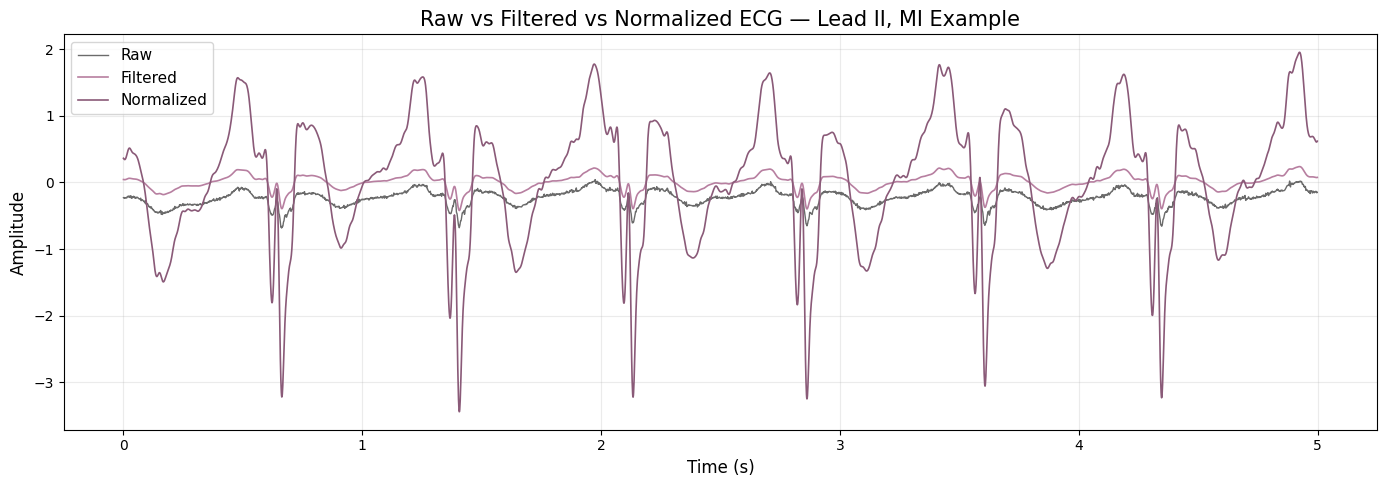

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook2_raw_filtered_normalized_lead_ii_mi.png


In [32]:
fig_path = FIGURE_DIR / "notebook2_raw_filtered_normalized_lead_ii_mi.png"

plot_raw_filtered_normalized_lead(
    raw_12lead,
    filtered_12lead,
    normalized_12lead,
    fs,
    selected_leads,
    lead_name="ii",
    title="Raw vs Filtered vs Normalized ECG — Lead II, MI Example",
    output_path=fig_path,
    start_sec=0,
    duration_sec=5
)

print("Saved figure to:", fig_path)

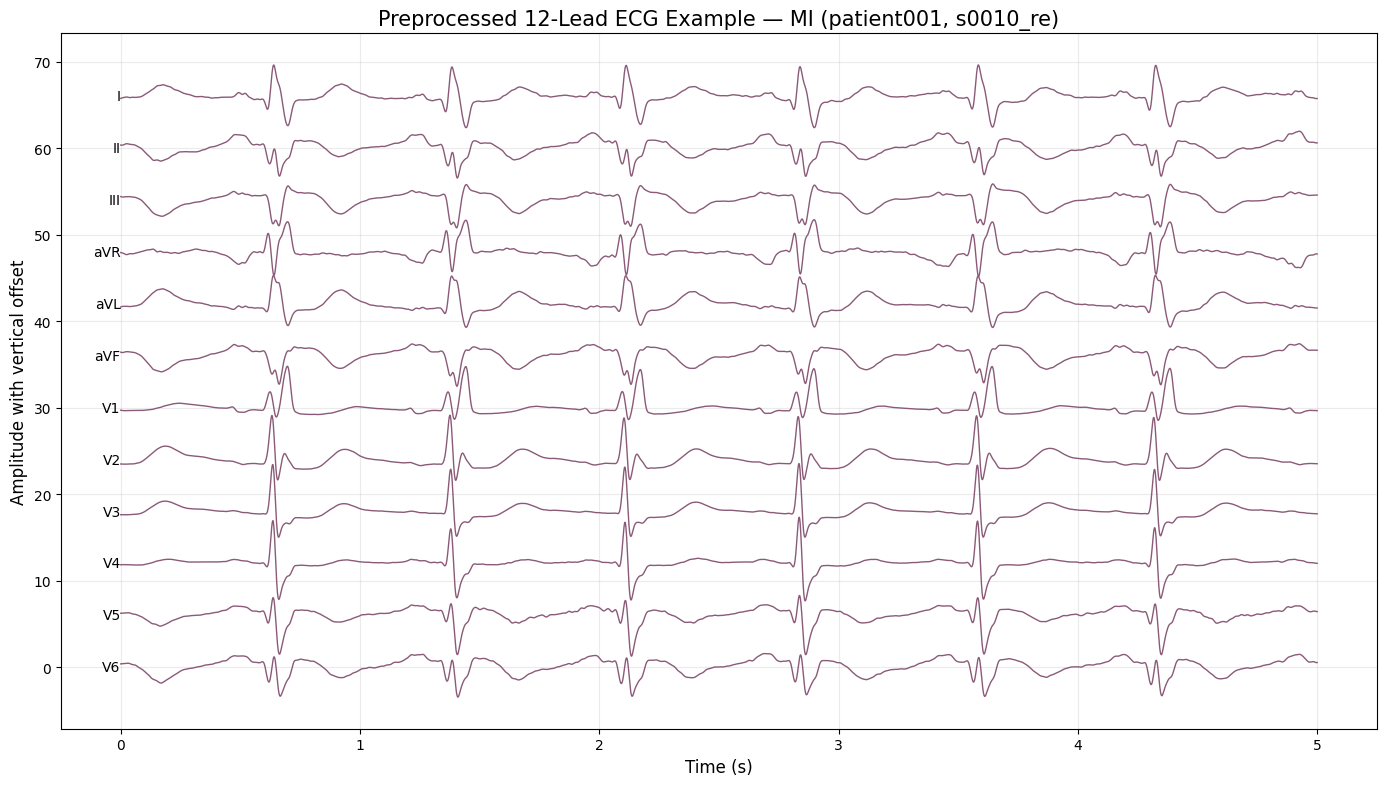

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook2_normalized_12lead_mi_example.png


In [33]:
fig_path = FIGURE_DIR / "notebook2_normalized_12lead_mi_example.png"

plot_multilead_ecg(
    normalized_12lead,
    fs,
    selected_leads,
    title=f"Preprocessed 12-Lead ECG Example — MI ({mi_example_row['patient_id']}, {mi_example_row['record_id']})",
    output_path=fig_path,
    start_sec=0,
    duration_sec=5,
    vertical_spacing=6
)

print("Saved figure to:", fig_path)

In [41]:
def plot_psd_before_after(
    raw_signal,
    filtered_signal,
    fs,
    lead_names,
    lead_name="ii",
    output_path=None
):
    lead_idx = lead_names.index(lead_name.lower())

    raw_lead = raw_signal[:, lead_idx]
    filtered_lead = filtered_signal[:, lead_idx]

    f_raw, pxx_raw = welch(raw_lead, fs=fs, nperseg=4096)
    f_filt, pxx_filt = welch(filtered_lead, fs=fs, nperseg=4096)

    plt.figure(figsize=(10, 5))
    plt.semilogy(f_raw, pxx_raw, label="Raw", color=GRAY)
    plt.semilogy(f_filt, pxx_filt, label="Filtered", color=PURPLE_DARK)

    plt.xlim(0, 100)
    plt.title(f"Power Spectral Density Before and After Filtering — Lead {LEAD_DISPLAY_NAMES.get(lead_name, lead_name)}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power spectral density")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

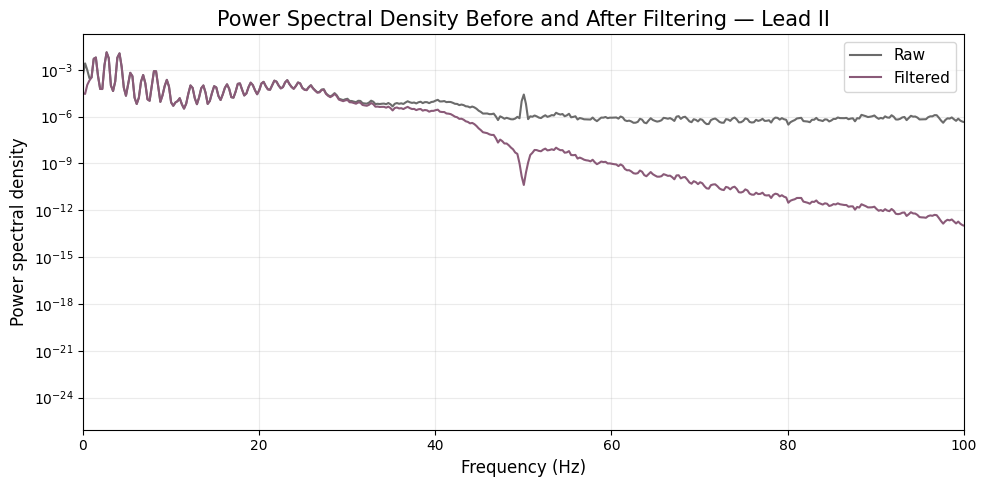

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook2_psd_before_after_filtering_lead_ii.png


In [42]:
fig_path = FIGURE_DIR / "notebook2_psd_before_after_filtering_lead_ii.png"

plot_psd_before_after(
    raw_12lead,
    filtered_12lead,
    fs,
    selected_leads,
    lead_name="ii",
    output_path=fig_path
)

print("Saved figure to:", fig_path)

In [36]:
example_records = pd.concat([
    detection_df[detection_df["mi_detected"] == 1].head(2),
    detection_df[detection_df["mi_detected"] == 0].head(2)
]).reset_index(drop=True)

display(example_records[["patient_id", "record_id", "reason_for_admission", "mi_detected", "record_path"]])

,patient_id,record_id,reason_for_admission,mi_detected,record_path
0,patient001,s0010_re,Myocardial infarction,1,ptb-diagnostic-ecg-database-1.0.0\patient001\s...
1,patient001,s0014lre,Myocardial infarction,1,ptb-diagnostic-ecg-database-1.0.0\patient001\s...
2,patient104,s0306lre,Healthy control,0,ptb-diagnostic-ecg-database-1.0.0\patient104\s...
3,patient105,s0303lre,Healthy control,0,ptb-diagnostic-ecg-database-1.0.0\patient105\s...


In [37]:
def plot_lead_examples(records_df, lead_name="ii", start_sec=0, duration_sec=5, output_path=None):
    n = len(records_df)

    plt.figure(figsize=(14, 3 * n))

    for idx, row in records_df.iterrows():
        signal, fs, lead_names, info = load_ecg_record(row["record_path"])
        signal_12lead, selected_leads = select_standard_12_leads(signal, lead_names)

        filtered, normalized, _ = preprocess_ecg_signal(signal_12lead, fs, PREPROCESSING_CONFIG)

        lead_idx = selected_leads.index(lead_name.lower())

        start_sample = int(start_sec * fs)
        end_sample = int((start_sec + duration_sec) * fs)
        t = np.arange(end_sample - start_sample) / fs + start_sec

        label = "MI" if row["mi_detected"] == 1 else "Healthy Control"

        plt.subplot(n, 1, idx + 1)
        plt.plot(
            t,
            normalized[start_sample:end_sample, lead_idx],
            color=PURPLE_DARK,
            linewidth=1.0
        )

        plt.title(f"{label} — {row['patient_id']} / {row['record_id']} — Lead {LEAD_DISPLAY_NAMES[lead_name]}")
        plt.xlabel("Time (s)")
        plt.ylabel("Normalized amplitude")
        plt.grid(alpha=0.25)

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

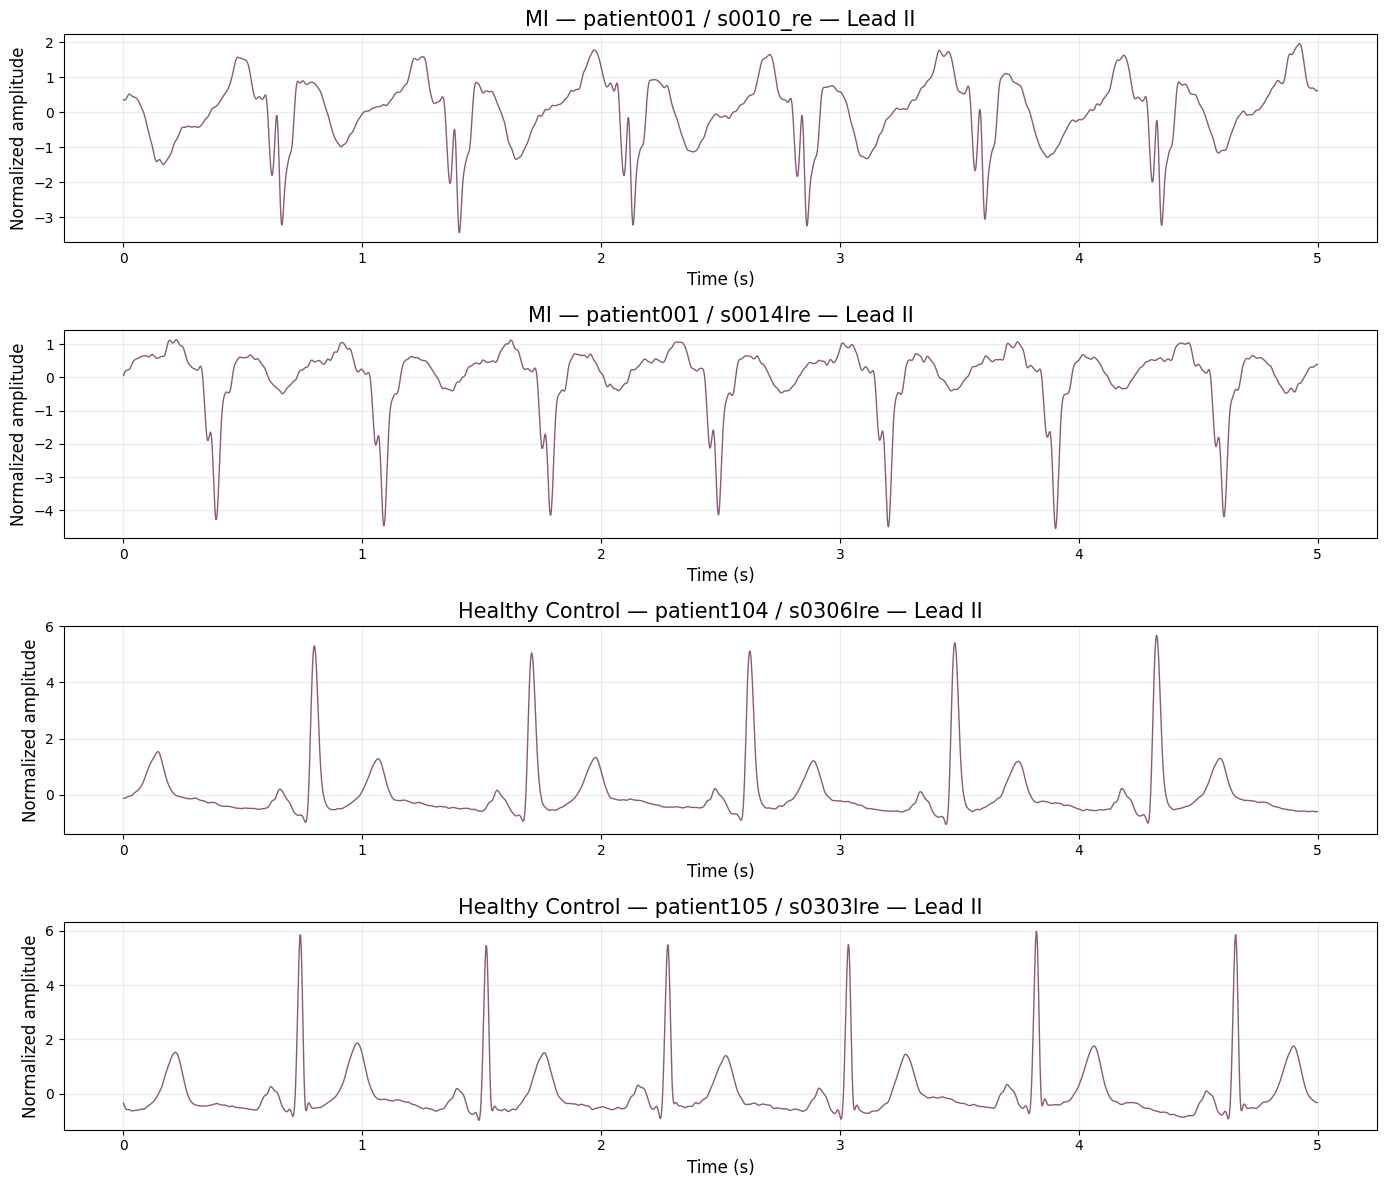

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook2_processed_lead_ii_examples.png


In [38]:
fig_path = FIGURE_DIR / "notebook2_processed_lead_ii_examples.png"

plot_lead_examples(
    example_records,
    lead_name="ii",
    start_sec=0,
    duration_sec=5,
    output_path=fig_path
)

print("Saved figure to:", fig_path)

In [39]:
config_output_path = TABLE_DIR / "notebook2_preprocessing_config.json"

with open(config_output_path, "w", encoding="utf-8") as f:
    json.dump(PREPROCESSING_CONFIG, f, indent=4)

print("Saved preprocessing configuration to:")
print(config_output_path)

Saved preprocessing configuration to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook2_preprocessing_config.json


In [40]:
config_output_path = TABLE_DIR / "notebook2_preprocessing_config.json"

with open(config_output_path, "w", encoding="utf-8") as f:
    json.dump(PREPROCESSING_CONFIG, f, indent=4)

print("Saved preprocessing configuration to:")
print(config_output_path)

Saved preprocessing configuration to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook2_preprocessing_config.json
